In [ ]:
#import os
#os.environ['CUDA_VISIBLE_DEVICES'] = '-1'  # This works for Metal too

import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np

#tf.config.set_visible_devices([], 'GPU')
#tf.config.set_soft_device_placement(True)

print(tf.config.list_physical_devices())  # Will return empty list


train_box = np.load('training_boxes.npy')
train_img = np.load('training_images.npy')
train_lb = np.load('training_labels.npy')
val_box = np.load('validation_boxes.npy')
val_img = np.load('validation_images.npy')
val_lb = np.load('validation_labels.npy')


[PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU')]


array([[[0.],
        [0.],
        [0.],
        ...,
        [0.],
        [0.],
        [0.]],

       [[0.],
        [0.],
        [0.],
        ...,
        [0.],
        [0.],
        [0.]],

       [[0.],
        [0.],
        [0.],
        ...,
        [0.],
        [0.],
        [0.]],

       ...,

       [[0.],
        [0.],
        [0.],
        ...,
        [0.],
        [0.],
        [0.]],

       [[0.],
        [0.],
        [0.],
        ...,
        [0.],
        [0.],
        [0.]],

       [[0.],
        [0.],
        [0.],
        ...,
        [0.],
        [0.],
        [0.]]], shape=(75, 75, 1), dtype=float32)

In [11]:
def my_create_model():
    inputs = tf.keras.layers.Input(shape=(75,75,1))
    c1 = tf.keras.layers.Conv2D(64, 3, activation='leaky_relu')(inputs)
    c2 = tf.keras.layers.MaxPooling2D((3,3))(c1)
    c3 = tf.keras.layers.Conv2D(64, 3, activation='leaky_relu')(c2)
    c4 = tf.keras.layers.MaxPooling2D((3,3))(c3)
    c5 = tf.keras.layers.Conv2D(64, 3, activation='leaky_relu')(c4)
    c6 = tf.keras.layers.MaxPooling2D((3,3))(c5)

    c7 = tf.keras.layers.Flatten()(c6)
    x = tf.keras.layers.Dense(128, activation='leaky_relu')(c7)

    # output del classificatore
    o1 = tf.keras.layers.Dense(10, activation='softmax', name='classifier')(x)
    
    # output del bounding box
    o2 = tf.keras.layers.Dense(4, name='regressor')(x)
    
    return tf.keras.Model(inputs=inputs, outputs=[o1, o2])

model = my_create_model()
model.compile(optimizer='adam', 
              loss={
                  'classifier': 'categorical_crossentropy',
                  'regressor': 'mse'
              },
              metrics={
                  'classifier':'accuracy',
                  'regressor':'mse'
              })

history = model.fit(train_img, (train_lb, train_box), epochs=5, validation_data=[val_img, (val_lb, val_box)])

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 48s 25ms/step - classifier_accuracy: 0.6155 - classifier_loss: 1.0544 - loss: 1.0711 - regressor_loss: 0.0167 - regressor_mse: 0.0167 - val_classifier_accuracy: 0.7357 - val_classifier_loss: 0.7292 - val_loss: 0.7383 - val_regressor_loss: 0.0091 - val_regressor_mse: 0.0091
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 46s 24ms/step - classifier_accuracy: 0.7516 - classifier_loss: 0.6950 - loss: 0.7033 - regressor_loss: 0.0082 - regressor_mse: 0.0082 - val_classifier_accuracy: 0.7657 - val_classifier_loss: 0.6464 - val_loss: 0.6542 - val_regressor_loss: 0.0078 - val_regressor_mse: 0.0078
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 46s 24ms/step - classifier_accuracy: 0.7717 - classifier_loss: 0.6295 - loss: 0.6363 - regressor_loss: 0.0068 - regressor_mse: 0.0068 - val_classifier_accuracy: 0.7725 - val_classifier_loss: 0.6269 - val_loss: 0.6333 - val_regressor_loss: 0.0067 - val_regressor_mse: 0.0067
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 46s 24ms/step 

Sua implementazione:

In [ ]:
from matplotlib.patches import Rectangle

def plot_sample(images, boxes, pboxes=None, plot_predictions=False):
    plt.figure(figsize=(10,10))
    for i in range(25):
        plt.subplot(5,5,i+1)
        plt.xticks([])
        plt.yticks([])
        plt.grid(False)
        plt.imshow(images[i], cmap='binary')
        center = (boxes[i, 0]*75, boxes[i,1]*75) 
        plt.gca().add_patch(Rectangle(
            center, 
            (boxes[i, 2] - boxes[i, 0])*75, # larghezza 
            (boxes[i, 3] - boxes[i, 1])*75,
            edgecolor='red',
            facecolor='none',
            lw=4
        ))
        
        if plot_predictions:
            center = (pboxes[i, 0]*75, pboxes[i,1]*75) 
            plt.gca().add_patch(Rectangle(
                center, 
                (pboxes[i, 2] - pboxes[i, 0])*75, # larghezza 
                (pboxes[i, 3] - pboxes[i, 1])*75,
                edgecolor='blue',
                facecolor='none',
                lw=4
            ))
    plt.show()

def feature_extractor(inputs):
    x = tf.keras.layers.Conv2D(16,3,activation="leaky_relu")(inputs)
    x = tf.keras.layers.AveragePooling2D((2,2))(x) # avg per variare
    x = tf.keras.layers.Conv2D(32,3,activation="leaky_relu")(x)
    x = tf.keras.layers.AveragePooling2D((2,2))(x) # avg per variare
    x = tf.keras.layers.Conv2D(64,3,activation="leaky_relu")(x)
    x = tf.keras.layers.AveragePooling2D((2,2))(x) # avg per variare
    x = tf.keras.layers.Flatten()(x)
    x = tf.keras.layers.Dense(128, activation='leaky_relu')(x)
    return x


def classifier(inputs):
    return tf.keras.layers.Dense(10, activation='softmax', name='classifier')(inputs)

def regressor(inputs):
    return tf.keras.layers.Dense(4, name='bounding_box')(inputs)

def create_model():
    inputs = tf.keras.layers.Input(shape=(75,75,1))
    dense_output = feature_extractor(inputs)
    classification_output = classifier(dense_output)
    regression_output = regressor(dense_output)

    model = tf.keras.Model(inputs=inputs, outputs=[classification_output, regression_output])
    return model


print(f"TensorFlow version: {tf.__version__}")
print(f"TensorFlow Metal version: {tf.test.is_built_with_cuda()}") # This indicates if the plugin loaded
print("Physical devices:", tf.config.list_physical_devices('GPU'))

TensorFlow version: 2.21.0
TensorFlow Metal version: False
Physical devices: []


313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step


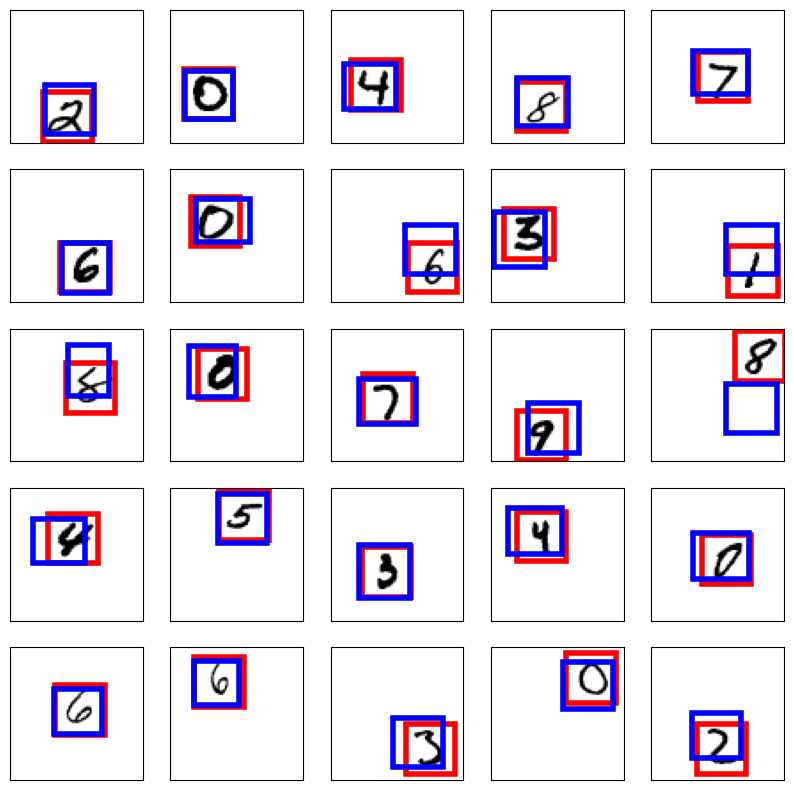

In [14]:
# mio modello:
def plot_history(history):
    fig, (ax1, ax2) = plt.subplots(1,2)
    ax1.plot(history.history['classifier_loss'], label='classifier loss')
    ax1.plot(history.history['val_classifier_loss'], label='val classifier loss')
    ax2.plot(history.history['bounding_box_loss'], label='bbox loss')
    ax2.plot(history.history['val_bounding_box_loss'], label='val bbox loss')
    ax1.legend()
    ax2.legend()
    plt.show()
    
#lot_history(history)
predictions = model.predict(val_img)
plot_sample(val_img, val_box, predictions[1], plot_predictions=True)

In [7]:
model = create_model()

model.compile(
    optimizer='adam',
    loss = {
        'classifier': 'categorical_crossentropy',
        'bounding_box': 'mse'
    },
    metrics = {
        'classifier': 'acc',
        'bounding_box': 'mse'
    }
)

model.summary()
history = model.fit(train_img, (train_lb, train_box),
                    validation_data=(val_img, (val_lb, val_box)),
                    epochs=5)


Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 75, 75, 1) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_6 (Conv2D)   │ (None, 73, 73,    │        160 │ input_layer_2[0]… │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ average_pooling2d_3 │ (None, 36, 36,    │          0 │ conv2d_6[0][0]    │
│ (AveragePooling2D)  │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_7 (Conv2D)   │ (None, 34, 34,    │      4,640 │ average_pooling2… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ average_pooling2d_4 │ (None, 17, 17,    │          0 │ conv2d_7[0][0]    │
│ (AveragePooling2D)  │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_8 (Conv2D)   │ (None, 15, 15,    │     18,496 │ average_pooling2… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ average_pooling2d_5 │ (None, 7, 7, 64)  │          0 │ conv2d_8[0][0]    │
│ (AveragePooling2D)  │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_2 (Flatten) │ (None, 3136)      │          0 │ average_pooling2… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 128)       │    401,536 │ flatten_2[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ classifier (Dense)  │ (None, 10)        │      1,290 │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bounding_box        │ (None, 4)         │        516 │ dense_2[0][0]     │
│ (Dense)             │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 426,638 (1.63 MB)

 Trainable params: 426,638 (1.63 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 34s 18ms/step - bounding_box_loss: 0.0094 - bounding_box_mse: 0.0094 - classifier_acc: 0.6949 - classifier_loss: 0.8795 - loss: 0.8888 - val_bounding_box_loss: 0.0062 - val_bounding_box_mse: 0.0062 - val_classifier_acc: 0.9112 - val_classifier_loss: 0.2952 - val_loss: 0.3017
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 32s 17ms/step - bounding_box_loss: 0.0040 - bounding_box_mse: 0.0040 - classifier_acc: 0.9216 - classifier_loss: 0.2566 - loss: 0.2606 - val_bounding_box_loss: 0.0030 - val_bounding_box_mse: 0.0030 - val_classifier_acc: 0.9411 - val_classifier_loss: 0.1957 - val_loss: 0.1989
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 29s 16ms/step - bounding_box_loss: 0.0022 - bounding_box_mse: 0.0022 - classifier_acc: 0.9444 - classifier_loss: 0.1808 - loss: 0.1830 - val_bounding_box_loss: 0.0019 - val_bounding_box_mse: 0.0019 - val_classifier_acc: 0.9390 - val_classifier_loss: 0.1911 - val_loss: 0.1932
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 27s 15ms

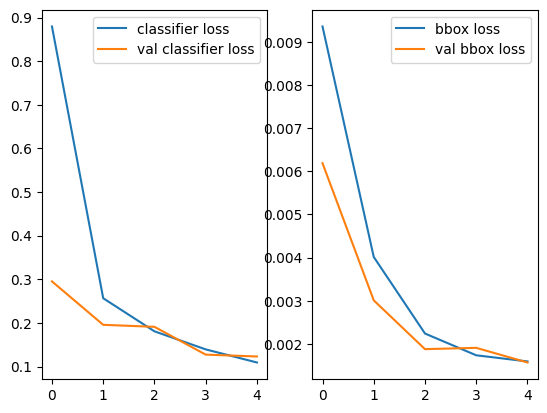

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step


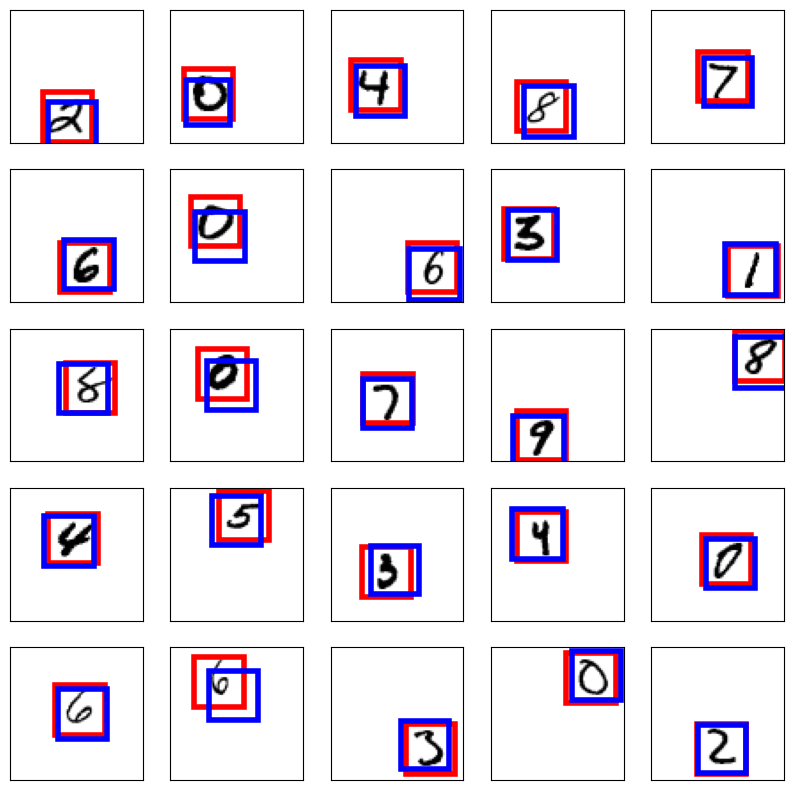

In [ ]:
plot_history(history)
predictions = model.predict(val_img)
plot_sample(val_img, val_box, predictions[1], plot_predictions=True)